# 03 - ECG Preprocessing And Scalogram Generation

This notebook implements the first deep-feature phase:

1. read raw `.mat/.hea` ECG records,
2. parse labels and metadata,
3. bandpass-filter selected ECG leads,
4. convert leads I, II, and V5 into a 3-channel CWT scalogram image,
5. save image files and a manifest CSV for EfficientNet feature extraction.

Start with a small sample. Once the output images look correct, increase `MAX_RECORDS`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

PROJECT_DIR = Path("..").resolve()
SRC_DIR = PROJECT_DIR / "src"
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(SRC_DIR))

from config import CONFIG
from ecg_io import LABEL_MAP, discover_records, load_ecg_mat
from handcrafted_features_v2 import HANDCRAFTED_FEATURES, extract_enhanced_handcrafted_features
from reproducibility import set_global_seed
from scalogram import DEFAULT_LEAD_INDICES, DEFAULT_LEAD_NAMES, build_3channel_scalogram, save_scalogram_png

seed_state = set_global_seed(CONFIG.seed)

print("Project:", PROJECT_DIR)
print("Raw dataset:", CONFIG.raw_dataset_dir)
print("Seed state:", seed_state)


Project: C:\Users\Admin\Desktop\Kshitiz\healthcare project\healthcare project
Raw dataset: C:\Users\Admin\Desktop\Kshitiz\Jennie mams thing finally staritng\Dataset\WFDBRecords
Seed state: {'seed': 42, 'python': True, 'numpy': True, 'torch': True, 'cuda': False}


## Configuration

Use `MAX_RECORDS` for quick testing. Recommended:

- `100` for visual smoke test,
- `1000` for first EfficientNet experiment,
- `None` for full dataset after everything works.


In [2]:
MODEL_NAME = CONFIG.active_model_name
MAX_RECORDS = CONFIG.active_max_records
TARGET_SIZE = CONFIG.model_target_size(MODEL_NAME)
OVERWRITE_IMAGES = False
CHECKPOINT_EVERY = CONFIG.checkpoint_every

SCALOGRAM_DIR = CONFIG.scalogram_dir(MODEL_NAME)
MANIFEST_PATH = CONFIG.scalogram_manifest_path(MODEL_NAME)
HANDCRAFTED_PATH = CONFIG.feature_dir / "enhanced_handcrafted_features.csv"
FAILED_PATH = CONFIG.manifest_dir / f"scalogram_failed_records_{MODEL_NAME}.csv"

SCALOGRAM_DIR.mkdir(parents=True, exist_ok=True)

records = discover_records(CONFIG.raw_dataset_dir, limit=MAX_RECORDS)
manifest_preview = pd.DataFrame([r.__dict__ for r in records])
manifest_preview["dx_codes"] = manifest_preview["dx_codes"].apply(lambda codes: ",".join(codes))

print("Model:", MODEL_NAME)
print("Target size:", TARGET_SIZE)
print("Scalogram output:", SCALOGRAM_DIR)
print(f"Discovered records: {len(records):,}")
display(manifest_preview[["record_id", "label", "label_name", "age", "sex", "sampling_frequency", "n_leads", "n_samples"]].head())
display(manifest_preview["label_name"].value_counts().rename_axis("label_name").reset_index(name="count"))


Model: efficientnet_b4
Target size: (380, 380)
Scalogram output: C:\Users\Admin\Desktop\Kshitiz\healthcare project\healthcare project\outputs\deep_features\scalograms_3ch_380
Discovered records: 1,000


,record_id,label,label_name,age,sex,sampling_frequency,n_leads,n_samples
0,JS00001,1,Arrhythmia,85,1,500,12,5000
1,JS00002,1,Arrhythmia,59,0,500,12,5000
2,JS00004,1,Arrhythmia,66,1,500,12,5000
3,JS00005,1,Arrhythmia,73,0,500,12,5000
4,JS00006,1,Arrhythmia,46,0,500,12,5000


,label_name,count
0,Arrhythmia,683
1,Normal,174
2,Other / Unknown,143


## Generate 3-Channel Scalograms

Each image channel represents a clinically useful lead:

- channel 0: Lead I,
- channel 1: Lead II,
- channel 2: Lead V5.


In [3]:
def load_existing(path):
    return pd.read_csv(path).to_dict("records") if path.exists() else []


rows = load_existing(MANIFEST_PATH)
failed = load_existing(FAILED_PATH)
handcrafted_rows = load_existing(HANDCRAFTED_PATH)

completed_ids = {str(row["record_id"]) for row in rows}
handcrafted_ids = {str(row["record_id"]) for row in handcrafted_rows}


def save_checkpoints():
    pd.DataFrame(rows).drop_duplicates("record_id", keep="last").to_csv(MANIFEST_PATH, index=False)
    pd.DataFrame(handcrafted_rows).drop_duplicates("record_id", keep="last").to_csv(HANDCRAFTED_PATH, index=False)
    pd.DataFrame(failed, columns=["record_id", "error"]).to_csv(FAILED_PATH, index=False)


for index, record in enumerate(tqdm(records, desc="Generating scalograms"), start=1):
    output_path = SCALOGRAM_DIR / f"{record.record_id}.png"

    try:
        needs_ecg = OVERWRITE_IMAGES or not output_path.exists() or record.record_id not in handcrafted_ids
        if needs_ecg:
            ecg = load_ecg_mat(record.mat_path)

        if OVERWRITE_IMAGES or not output_path.exists():
            image = build_3channel_scalogram(
                ecg,
                fs=record.sampling_frequency,
                lead_indices=DEFAULT_LEAD_INDICES,
                target_size=TARGET_SIZE,
            )
            save_scalogram_png(image, output_path)

        if record.record_id not in completed_ids:
            rows.append({
                "record_id": record.record_id,
                "mat_path": str(record.mat_path),
                "hea_path": str(record.hea_path),
                "image_path": str(output_path),
                "label": record.label,
                "label_name": record.label_name,
                "age": record.age,
                "sex": record.sex,
                "dx_codes": ",".join(record.dx_codes),
                "sampling_frequency": record.sampling_frequency,
                "n_leads": record.n_leads,
                "n_samples": record.n_samples,
                "lead_indices": ",".join(map(str, DEFAULT_LEAD_INDICES)),
                "lead_names": ",".join(DEFAULT_LEAD_NAMES),
                "image_height": TARGET_SIZE[1],
                "image_width": TARGET_SIZE[0],
            })
            completed_ids.add(record.record_id)

        if record.record_id not in handcrafted_ids:
            features = extract_enhanced_handcrafted_features(
                ecg[1],
                fs=record.sampling_frequency,
            )
            handcrafted_rows.append({
                "record_id": record.record_id,
                "label": record.label,
                "label_name": record.label_name,
                "age": record.age,
                "sex": record.sex,
                **{name: features[name] for name in HANDCRAFTED_FEATURES},
            })
            handcrafted_ids.add(record.record_id)
    except Exception as exc:
        failed.append({"record_id": record.record_id, "error": str(exc)})

    if index % CHECKPOINT_EVERY == 0:
        save_checkpoints()

save_checkpoints()
scalogram_manifest = pd.read_csv(MANIFEST_PATH)
failed_df = pd.read_csv(FAILED_PATH)

print(f"Saved manifest: {MANIFEST_PATH}")
print(f"Saved handcrafted features: {HANDCRAFTED_PATH}")
print(f"Generated/available images: {len(scalogram_manifest):,}")
print(f"Failed records: {len(failed_df):,}")
display(scalogram_manifest.head())


Generating scalograms:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved manifest: C:\Users\Admin\Desktop\Kshitiz\healthcare project\healthcare project\outputs\deep_features\manifests\scalogram_manifest_3ch_380.csv
Saved handcrafted features: C:\Users\Admin\Desktop\Kshitiz\healthcare project\healthcare project\outputs\deep_features\features\enhanced_handcrafted_features.csv
Generated/available images: 1,000
Failed records: 0


,record_id,mat_path,hea_path,image_path,label,label_name,age,sex,dx_codes,sampling_frequency,n_leads,n_samples,lead_indices,lead_names,image_height,image_width
0,JS00001,C:\Users\Admin\Desktop\Kshitiz\Jennie mams thi...,C:\Users\Admin\Desktop\Kshitiz\Jennie mams thi...,C:\Users\Admin\Desktop\Kshitiz\healthcare proj...,1,Arrhythmia,85,1,"164889003,59118001,164934002",500,12,5000,"0,1,10","I,II,V5",380,380
1,JS00002,C:\Users\Admin\Desktop\Kshitiz\Jennie mams thi...,C:\Users\Admin\Desktop\Kshitiz\Jennie mams thi...,C:\Users\Admin\Desktop\Kshitiz\healthcare proj...,1,Arrhythmia,59,0,"426177001,164934002",500,12,5000,"0,1,10","I,II,V5",380,380
2,JS00004,C:\Users\Admin\Desktop\Kshitiz\Jennie mams thi...,C:\Users\Admin\Desktop\Kshitiz\Jennie mams thi...,C:\Users\Admin\Desktop\Kshitiz\healthcare proj...,1,Arrhythmia,66,1,426177001,500,12,5000,"0,1,10","I,II,V5",380,380
3,JS00005,C:\Users\Admin\Desktop\Kshitiz\Jennie mams thi...,C:\Users\Admin\Desktop\Kshitiz\Jennie mams thi...,C:\Users\Admin\Desktop\Kshitiz\healthcare proj...,1,Arrhythmia,73,0,"164890007,429622005,428750005",500,12,5000,"0,1,10","I,II,V5",380,380
4,JS00006,C:\Users\Admin\Desktop\Kshitiz\Jennie mams thi...,C:\Users\Admin\Desktop\Kshitiz\Jennie mams thi...,C:\Users\Admin\Desktop\Kshitiz\healthcare proj...,1,Arrhythmia,46,0,426177001,500,12,5000,"0,1,10","I,II,V5",380,380


## Visual Quality Check

This cell displays one sample image from each class when available. The image should show structured time-frequency bands, not a blank or single-color square.


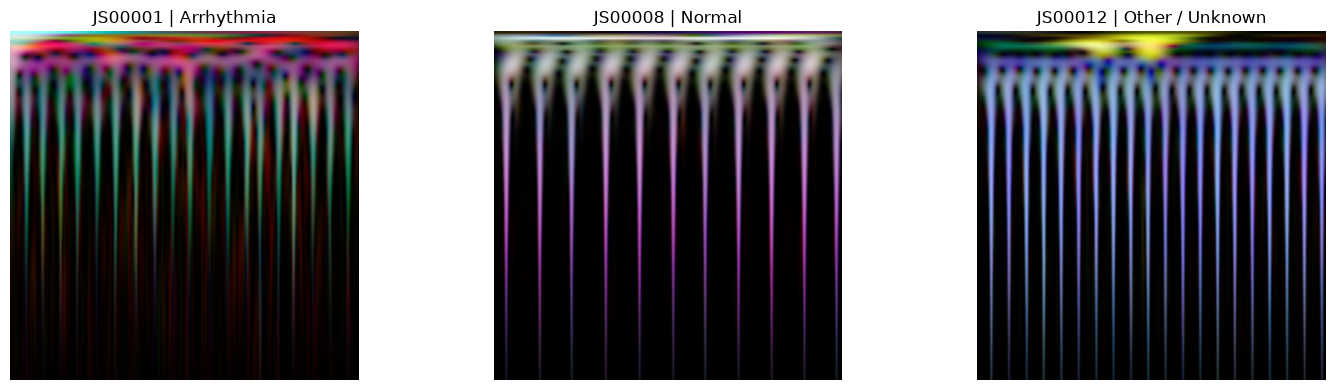

In [4]:
from PIL import Image

examples = (
    scalogram_manifest
    .sort_values("record_id")
    .groupby("label_name", as_index=False)
    .head(1)
)

fig, axes = plt.subplots(1, len(examples), figsize=(5 * len(examples), 4))
if len(examples) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, examples.iterrows()):
    img = Image.open(row["image_path"])
    ax.imshow(img)
    ax.set_title(f"{row['record_id']} | {row['label_name']}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Next Output

The next notebook, `04_efficientnet_embeddings.ipynb`, reads:

`outputs/deep_features/manifests/scalogram_manifest_3ch_224.csv`

and extracts EfficientNet embeddings from these saved images.
